In [ ]:
https://raw.githubusercontent.com/BryanJimenezUtec/JimenezBryan_2520552022/refs/heads/main/Data/clave_H_agrupacion.csv

In [7]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv('https://raw.githubusercontent.com/BryanJimenezUtec/JimenezBryan_2520552022/refs/heads/main/Data/clave_H_agrupacion.csv')

In [10]:
print("=== 1. ESTRUCTURA GENERAL DEL DATASET ===")
print(df.info())

=== 1. ESTRUCTURA GENERAL DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   registro_id       258 non-null    object 
 1   edad              258 non-null    int64  
 2   ingresos          258 non-null    int64  
 3   frecuencia_uso    258 non-null    float64
 4   gasto_promedio    258 non-null    float64
 5   satisfaccion      257 non-null    float64
 6   reclamos          258 non-null    int64  
 7   antiguedad_meses  258 non-null    int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 16.3+ KB
None


In [11]:
# 2. SELECCIÓN DE VARIABLES ADECUADAS PARA CLUSTERING
variables_clave = ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']
df_clustering = df[variables_clave]

print("\n=== 2. VARIABLES SELECCIONADAS DE FORMA ADECUADA ===")
print(df_clustering.columns.tolist())

print("\n=== 3. VISTA PREVIA DE LA MATRIZ DE SEGMENTACIÓN ===")
print(df_clustering.head())


=== 2. VARIABLES SELECCIONADAS DE FORMA ADECUADA ===
['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']

=== 3. VISTA PREVIA DE LA MATRIZ DE SEGMENTACIÓN ===
   edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
0    48      1292            9.60          158.47          8.45         0   
1    39       707            6.72           73.85          2.99         6   
2    37      1100            4.02           79.86          3.68         4   
3    35       582            3.25           44.88          5.18        12   
4    37      1191            6.66           55.80          7.96         1   

   antiguedad_meses  
0                37  
1                 1  
2                 4  
3                 8  
4                23  


In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [13]:
df_limpio = df.copy()

In [14]:
df_limpio['satisfaccion'] = df_limpio['satisfaccion'].fillna(df_limpio['satisfaccion'].median())

variables_clave = ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']
df_clustering = df_limpio[variables_clave]

scaler = StandardScaler()

# Ajustamos el escalador con nuestros datos y los transformamos
datos_escalados = scaler.fit_transform(df_clustering)

# Convertimos el resultado de vuelta a un DataFrame de Pandas para mantener el orden
df_escalado = pd.DataFrame(datos_escalados, columns=variables_clave)

print("--- Primeras filas de los datos correctamente escalados ---")
print(df_escalado.head())

--- Primeras filas de los datos correctamente escalados ---
       edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
0  0.702228  0.385652        1.378570        1.499559      0.817422 -1.218790   
1 -0.175841 -0.933803        0.380390       -0.242766     -2.167405  1.775951   
2 -0.370967 -0.047400       -0.555404       -0.119021     -1.790201  0.777704   
3 -0.566093 -1.215738       -0.822279       -0.839258     -0.970194  4.770692   
4 -0.370967  0.157849        0.359594       -0.614416      0.549553 -0.719666   

   antiguedad_meses  
0          1.416909  
1         -1.246570  
2         -1.024614  
3         -0.728672  
4          0.381112  


In [15]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [16]:
# 1. Creamos una lista vacía para almacenar la inercia de cada intento
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_escalado)  # Entrenamos el modelo con los datos normalizados
    wcss.append(kmeans.inertia_)

¡Gráfico 'metodo_codo.png' generado y guardado!


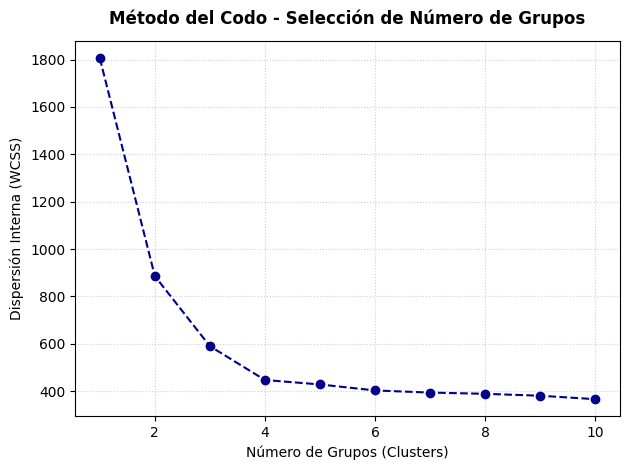

In [17]:
# Limpiamos cualquier gráfico previo en la memoria
plt.clf()

# Dibujamos la línea con marcadores circulares en cada punto
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='darkblue')

# Añadimos los títulos y etiquetas legibles para el informe
plt.title('Método del Codo - Selección de Número de Grupos', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Número de Grupos (Clusters)', fontsize=10)
plt.ylabel('Dispersión Interna (WCSS)', fontsize=10)

# Activamos una cuadrícula suave de fondo para identificar mejor los puntos
plt.grid(True, linestyle=':', alpha=0.6)

# Ajustamos márgenes para evitar textos cortados y guardamos la imagen
plt.tight_layout()
plt.savefig('metodo_codo.png')

print("¡Gráfico 'metodo_codo.png' generado y guardado!")

In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [19]:
df_limpio = df.copy()
df_limpio['satisfaccion'] = df_limpio['satisfaccion'].fillna(df_limpio['satisfaccion'].median())

variables_clave = ['edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos', 'antiguedad_meses']
df_clustering = df_limpio[variables_clave]

In [20]:
scaler = StandardScaler()
df_escalado = scaler.fit_transform(df_clustering)

In [21]:
modelo_kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

df_limpio['Grupo_Cliente'] = modelo_kmeans.fit_predict(df_escalado)

In [22]:
resumen_grupos = df_limpio.groupby('Grupo_Cliente')[variables_clave].mean()

print("=== PERFIL PROMEDIO DE LOS 3 GRUPOS ENCONTRADOS ===")
print(resumen_grupos)

df_limpio.to_csv('clientes_segmentados_final.csv', index=False)
print("\n¡Resultados guardados exitosamente en 'clientes_segmentados_final.csv'!")

=== PERFIL PROMEDIO DE LOS 3 GRUPOS ENCONTRADOS ===
                    edad     ingresos  frecuencia_uso  gasto_promedio  \
Grupo_Cliente                                                           
0              38.704225  1117.690141        6.591690       86.681690   
1              35.508065   808.080645        3.305726       48.263629   
2              53.587302  1740.698413        9.090159      158.034286   

               satisfaccion  reclamos  antiguedad_meses  
Grupo_Cliente                                            
0                  8.083380  1.253521         17.647887  
1                  5.370000  3.967742          8.475806  
2                  8.801905  0.777778         36.523810  

¡Resultados guardados exitosamente en 'clientes_segmentados_final.csv'!


In [23]:
df_final = df.copy()

# 2. Le añadimos la columna 'cluster' con los resultados que calculó el modelo K-Means
# Esto asignará a cada fila su respectivo grupo (0, 1 o 2) correspondientes a su perfil
df_final['cluster'] = modelo_kmeans.labels_

In [24]:
print("=== Estructura del Dataset Original con la Nueva Columna ===")
# Imprimimos las primeras filas para comprobar que al final de la tabla aparezca la columna 'cluster'
print(df_final.head())

# Guardamos el archivo final en el entorno de Colab en formato CSV
df_final.to_csv('clave_H_agrupado_con_clusters.csv', index=False)

print("\n¡Éxito! Columna agregada y archivo 'clave_H_agrupado_con_clusters.csv' guardado.")

=== Estructura del Dataset Original con la Nueva Columna ===
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     H-R0158    48      1292            9.60          158.47          8.45   
1     H-R0209    39       707            6.72           73.85          2.99   
2     H-R0257    37      1100            4.02           79.86          3.68   
3     H-R0037    35       582            3.25           44.88          5.18   
4     H-R0132    37      1191            6.66           55.80          7.96   

   reclamos  antiguedad_meses  cluster  
0         0                37        2  
1         6                 1        1  
2         4                 4        1  
3        12                 8        1  
4         1                23        0  

¡Éxito! Columna agregada y archivo 'clave_H_agrupado_con_clusters.csv' guardado.


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
plt.clf()

# 2. Configurar el tema visual de fondo (cuadrícula clara y estética)
sns.set_theme(style="whitegrid")

<Figure size 640x480 with 0 Axes>

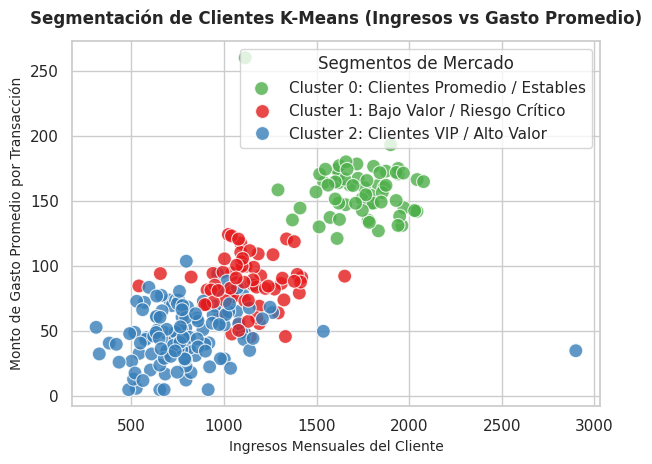

In [27]:
sns.scatterplot(
    data=df_final,
    x='ingresos',
    y='gasto_promedio',
    hue='cluster',
    palette='Set1',
    alpha=0.8,
    s=100
)

# 4. Añadir títulos y etiquetas profesionales para tu reporte
plt.title('Segmentación de Clientes K-Means (Ingresos vs Gasto Promedio)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Ingresos Mensuales del Cliente', fontsize=10)
plt.ylabel('Monto de Gasto Promedio por Transacción', fontsize=10)

# 5. Modificar la leyenda para que sea completamente descriptiva y gerencial
plt.legend(
    title='Segmentos de Mercado',
    labels=['Cluster 0: Clientes Promedio / Estables',
            'Cluster 1: Bajo Valor / Riesgo Crítico',
            'Cluster 2: Clientes VIP / Alto Valor']
)

# 6. Ajustar márgenes para evitar recortes de texto y guardar la imagen
plt.tight_layout()
plt.savefig('visualizacion_clusters.png')

# 7. Mostrar la gráfica en la pantalla de Colab
plt.show()